In [1]:
from astropy import units as u
from astropy import time
import astropy
import numpy as np

from poliastro import iod
from poliastro.bodies import Body,Mars, Earth, Venus, Jupiter, Saturn, Uranus, Neptune, Sun, Europa, Ganymede, Callisto, Io, Titan
from poliastro.ephem import Ephem
from poliastro.maneuver import Maneuver
from poliastro.twobody import Orbit
from poliastro.util import time_range
from poliastro.frames import Planes
from poliastro.frames.fixed import JupiterFixed
from poliastro.frames.equatorial import JupiterICRS
from astroquery.jplhorizons import Horizons
from copy import deepcopy

from scipy import ndimage
from scipy.spatial.transform import Rotation as scipyRot
from collections import defaultdict
from poliastro.plotting import OrbitPlotter3D, StaticOrbitPlotter
import math
import matplotlib.pyplot as plt
# More info: https://plotly.com/python/renderers/
import plotly.io as pio
from poliastro.util import norm, time_range
pio.renderers.default = "plotly_mimetype+notebook_connected"
import weakref
from astropy.coordinates import solar_system_ephemeris
from collections.abc import Mapping
from poliastro.extra_util import get_galilean_orbs, ecliptic_slingshot, get_galilean_ephemerides, slingshot_to_another_body
# from poliastro.extra_util import *
solar_system_ephemeris.set("jpl")

from libs import jovian_spenvis_model

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "utctai" yielded 1 of "dubious year (Note 3)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"



In [2]:
model = jovian_spenvis_model.build_fast_e_p_spectrum_lookup("tests/spenvis_files/spenvis_spe.txt", "tests/spenvis_files/spenvis_spp.txt")


In [3]:
r_perijove = 1.5*Jupiter.R 
r_apijove = 95*Jupiter.R
a_start = (r_perijove+r_apijove)/2
ecc_start = (r_perijove-r_apijove)/(r_perijove+r_apijove)

start_date= time.Time("2037-06-11 00:01", scale="utc").tdb
end_date=start_date+20*u.day

starship_orb=Orbit.from_classical(
Jupiter, a_start, ecc_start, 0*u.deg, 
0*u.deg, 0*u.deg, -179*u.deg,
start_date,plane=Planes.EARTH_ECLIPTIC)

In [4]:
def tid_for_orbit(orbit,start,end,step=0.1*u.day):
    cum_tid=0
    flux=[]
    times=[]
    periods=int(((end-start).to(u.day)/step).value)
    for t in (time_range(start=start,end=end,periods=periods)):
        test_orb=orbit.propagate(t)
        r=((np.linalg.norm(test_orb.r))/Jupiter.R).to(u.one)
        # print(r)
        inst_flux=jovian_spenvis_model.electron_flux_gt2MeV(r,model)
        flux.append(inst_flux)
        times.append((t-start).to(u.hour).value)
        cum_tid+=inst_flux
        
    return cum_tid,flux,times
    

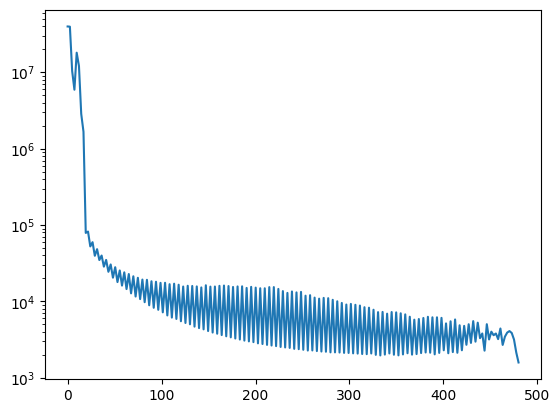

In [5]:
total,fluxes,times=tid_for_orbit(starship_orb,start_date,end_date)
plt.semilogy(times,fluxes)


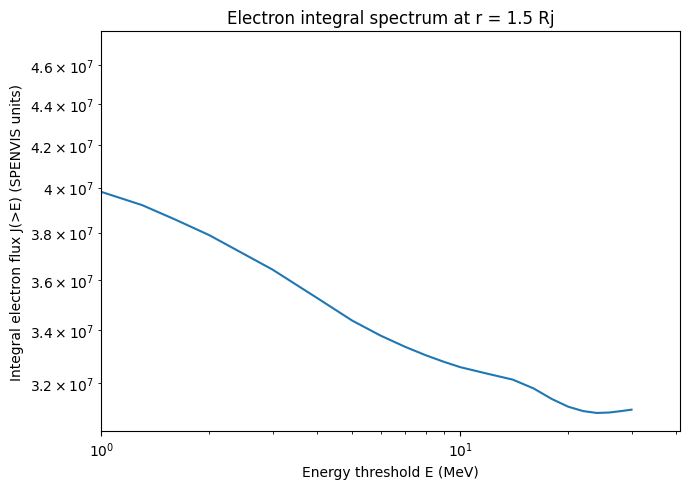

In [10]:
spec = jovian_spenvis_model.electron_spectrum_at_radius(model, 1.5)

E = spec["E_thr_MeV"]
J = np.asarray(spec["Jint_gt_E"], float)

plt.figure(figsize=(7,5))
plt.plot(E, np.clip(J, 1e-30, None))
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy threshold E (MeV)")
plt.ylabel("Integral electron flux J(>E) (SPENVIS units)")
plt.xlim(left=1)
plt.title("Electron integral spectrum at r = 1.5 Rj")
plt.tight_layout()
plt.show()

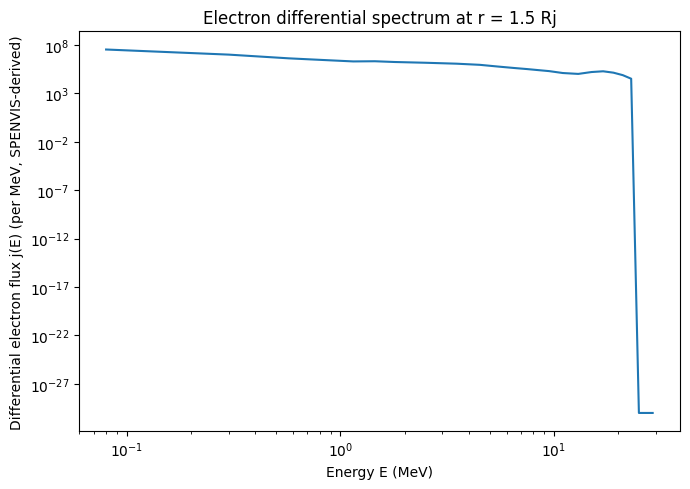

In [9]:
E_mid = spec["E_mid_MeV"]
j = np.asarray(spec["jd_MeV"], float)

plt.figure(figsize=(7,5))
plt.plot(E_mid, np.clip(j, 1e-30, None))
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy E (MeV)")
plt.ylabel("Differential electron flux j(E) (per MeV, SPENVIS-derived)")
plt.title("Electron differential spectrum at r = 1.5 Rj")
plt.tight_layout()
plt.show()
